<a href="https://colab.research.google.com/github/Gabriel-Orlandi-Portes/Analise-Album-Copa2026/blob/main/analise_album_copa2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. 📊 Análise das Simulações do Álbum da Copa do Mundo 2026**

Este notebook tem como objetivo analisar os dados gerados através das simulações do álbum da Copa do Mundo 2026.

A simulação foi criada em Python e tem como objetivo estimar:

- Quantidade de pacotes necessários para completar o álbum
- Custo total da coleção
- Quantidade de figurinhas repetidas
- Diferença entre repetidas normais e brilhantes
- Distribuição dos resultados obtidos

Os dados utilizados neste notebook foram gerados através do arquivo `1000_simulacoes.py`.




---


# **2. 📚 Importação das Bibliotecas**

Nesta etapa serão importadas as bibliotecas utilizadas durante a análise:

- Pandas: manipulação e análise dos dados
- Matplotlib: criação das visualizações gráficas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!




---


#**3. 📥 Carregamento e Leitura dos Dados**

Os dados utilizados na análise estão armazenados no arquivo `simulacoes.csv`.

*   O arquivo será carregado utilizando o Pandas para criação de um DataFrame.

*   O DataFrame será utilizado para realizar todas as análises posteriores.

In [2]:
# Selecionar arquivo simulacoes.csv

from google.colab import files

uploaded = files.upload()

#CASO ESTEJA USANDO O VS CODE UTILIZAR O CÓDIGO ABAIXO:
#df = pd.read_csv("../data/simulacoes.csv")

Saving simulacoes.csv to simulacoes.csv


In [3]:
# Carregando a tabela...

df = pd.read_csv('simulacoes.csv')

print('Tabela carregada com sucesso!')

Tabela carregada com sucesso!


---


#**4. 🔎 Exploração Inicial dos Dados**

Antes de iniciar as análises, será realizada uma exploração inicial do dataset.

O objetivo é entender:

- Estrutura dos dados
- Quantidade de registros
- Tipos das variáveis
- Estatísticas básicas

In [4]:
# Visualização inicial dos dados.

df.head()

,pacotes,custo,repetidas_total,repetidas_normais,repetidas_brilhantes
0,1160,8195,7140,6650,490
1,944,6683,5628,5187,441
2,833,5906,4851,4486,365
3,854,6053,4998,4655,343
4,1055,7460,6405,5940,465


In [5]:
# Quantidade de linhas e colunas.

df.shape

(1000, 5)

In [6]:
# Variáveis e dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   pacotes               1000 non-null   int64
 1   custo                 1000 non-null   int64
 2   repetidas_total       1000 non-null   int64
 3   repetidas_normais     1000 non-null   int64
 4   repetidas_brilhantes  1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB


In [7]:
# Dados Estatísticos da tabela

df.describe()

,pacotes,custo,repetidas_total,repetidas_normais,repetidas_brilhantes
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1045.560000,7393.920000,6338.920000,5898.275000,440.645000
std,182.725595,1279.079165,1279.079165,1190.468144,91.409292
min,669.000000,4758.000000,3703.000000,3412.000000,266.000000
25%,920.000000,6515.000000,5460.000000,5074.750000,376.000000
50%,1013.000000,7166.000000,6111.000000,5684.500000,426.000000
75%,1131.250000,7993.750000,6938.750000,6457.000000,486.000000
max,1881.000000,13242.000000,12187.000000,11298.000000,889.000000


In [77]:
# Padronizando nome das colunas para facilitar a análise

df.rename(
    columns={
        'pacotes': 'pacotes_comprados',
        'custo': 'custo_total'
    },
    inplace=True
)

---

Agora, serão analisadas medidas estatísticas para compreender a distribuição dos resultados.

Essas métricas permitem avaliar não apenas o resultado médio, mas também a variação entre diferentes simulações.

**Média:**
* A média é uma medida de tendência central que representa o valor médio de um conjunto de dados.

* Ela é calculada através da soma de todos os valores observados, dividida pela quantidade total de elementos.

*  A função **mean()** da biblioteca Pandas realiza automaticamente o cálculo da média.

**Valores Mínimos e Máximos**

* Os valores mínimo e máximo representam os extremos encontrados dentro das simulações.

* O valor mínimo indica a menor quantidade de pacotes necessária para completar o álbum entre todos os testes realizados.

* Já o valor máximo representa o cenário onde foi necessário comprar a maior quantidade de pacotes.

* Essas medidas ajudam a observar a variação existente entre diferentes simulações.

* Também utiliza funções da biblioteca Pandas **min() e max()**

**Mediana**

* A mediana representa o valor central de um conjunto de dados ordenados.

* Isso significa que metade das simulações apresentou um resultado menor ou igual à mediana, enquanto a outra metade apresentou um resultado maior ou igual.

* Essa métrica é importante porque reduz o impacto de valores muito altos ou muito baixos que podem influenciar a média.

**Quartis**

* Os quartis dividem os dados em quatro partes iguais, permitindo analisar melhor a distribuição dos resultados.

* Eles ajudam a identificar como os valores estão concentrados dentro das simulações.

* Neste projeto serão analisados:

  - Primeiro quartil (25%)
  - Mediana (50%)
  - Terceiro quartil (75%)

* Essas informações mostram a faixa onde está concentrada a maior parte dos resultados.



---


#**5. 📦 Análise da Quantidade de Pacotes Necessários**


####**5.1 Média**


In [9]:
media_pacotes = df["pacotes_comprados"].mean()

print(f'Média de pacotes necessários: {media_pacotes:.0f}')

Média de pacotes necessários: 1046


**Conclusão**

Com base nas 1.000 simulações realizadas, foi encontrada uma média de aproximadamente **1046 pacotes necessários** para completar o álbum.

Isso significa que, seguindo o modelo da simulação e sem realizar trocas de figurinhas, um colecionador precisaria comprar em torno dessa quantidade de pacotes para conseguir todas as figurinhas.

---

####**5.2 Valores Mínimos e Máximos**

In [78]:
menor_quantidade = df['pacotes_comprados'].min()
maior_quantidade = df['pacotes_comprados'].max()

print(f'Menor quantidade encontrada: {menor_quantidade}')
print(f'Maior quantidade encontrada: {maior_quantidade}')

Menor quantidade encontrada: 669
Maior quantidade encontrada: 1881


**Conclusão**

Entre todas as simulações realizadas, o melhor cenário conseguiu completar o álbum com apenas **669 pacotes**, enquanto o pior cenário precisou de **1881 pacotes**.

Essa diferença mostra o impacto da aleatoriedade na compra dos pacotes, já que cada simulação possui resultados diferentes mesmo utilizando as mesmas regras.

---

####**5.3 Mediana**


In [79]:
mediana_pacotes = df["pacotes_comprados"].median()

print(f'Mediana de pacotes: {mediana_pacotes:.0f}')

Mediana de pacotes: 1013


**Conclusão**

A mediana encontrada foi de **1013 pacotes**.

Isso significa que metade das simulações conseguiu completar o álbum utilizando uma quantidade menor ou igual a esse valor, enquanto a outra metade precisou de uma quantidade maior.

Como a mediana ficou próxima da média de **1046 pacotes**, os resultados apresentam uma distribuição equilibrada, sem grande influência de valores muito fora do padrão.

---

####**5.4 Quartis**



In [12]:
quartis_pacotes = df["pacotes_comprados"].quantile([0.25, 0.50, 0.75])

quartis_pacotes

,pacotes_comprados
0.25,920.00
0.50,1013.00
0.75,1131.25


**Conclusão**

Os quartis permitem observar onde está concentrada a maior parte das simulações.

*   De acordo com os dados, 25% dos casos, ou seja, aproximadamente 250 pessoas
terminaram o álbum comprando até 920 pacotes

* Como também 75% das simulações terminaram com até 1131 pacotes.

* Com isso, fica claro que 50% das simulaçoes precisaram de 920 à 1131 pacotes para completar o álbum.



---

#### **5.5 Análise da distribuição de pacotes necessários para completar o álbum**

O histograma abaixo apresenta a distribuição da quantidade de pacotes nas simulações.

Essa visualização permite observar se os valores ficaram concentrados próximos da média ou se houve grande variação entre os resultados.

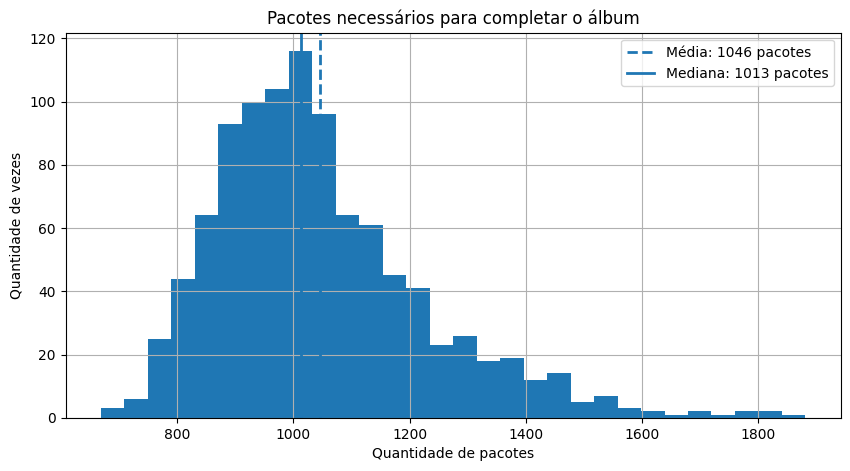

In [80]:
plt.figure(figsize=(10,5))

plt.hist(df["pacotes_comprados"], bins=30)

plt.axvline(
    media_pacotes,
    linestyle="--",
    linewidth=2,
    label=f'Média: {media_pacotes:.0f} pacotes'
)

plt.axvline(
    mediana_pacotes,
    linestyle="-",
    linewidth=2,
    label=f'Mediana: {mediana_pacotes:.0f} pacotes'
)

plt.title('Pacotes necessários para completar o álbum')
plt.xlabel('Quantidade de pacotes')
plt.ylabel('Quantidade de vezes')

plt.legend()
plt.grid(True)
plt.show()

**Conclusão**

O histograma permite visualizar a distribuição da quantidade de pacotes necessários para completar o álbum nas 1.000 simulações realizadas.

A maior parte dos resultados ficou concentrada próxima da faixa de aproximadamente **1.000 pacotes**, indicando que esse é o comportamento mais comum encontrado nas simulações.

A média encontrada foi de aproximadamente **1046 pacotes**, enquanto a mediana foi de **1013 pacotes**. Como os dois valores estão próximos, é possível observar que a distribuição dos resultados não sofreu grande influência de valores extremos.

---

####**5.6 Gráfico BloxPlot**

O boxplot permite visualizar a distribuição dos resultados das simulações.

Os principais elementos representam:

- **Linha central da caixa:** representa a mediana, indicando o valor central dos dados ordenados.
- **Caixa (entre Q1 e Q3):** representa o intervalo onde estão concentrados 50% dos resultados.
- **Limite inferior e superior da caixa:** representam o primeiro e terceiro quartil.
- **Bigodes:** mostram a variação dos valores dentro do limite considerado normal.
- **Pontos fora dos bigodes (outliers):** representam resultados muito diferentes da maioria das simulações.

Neste projeto, o boxplot ajuda a observar a variação da quantidade de pacotes necessários para completar o álbum.

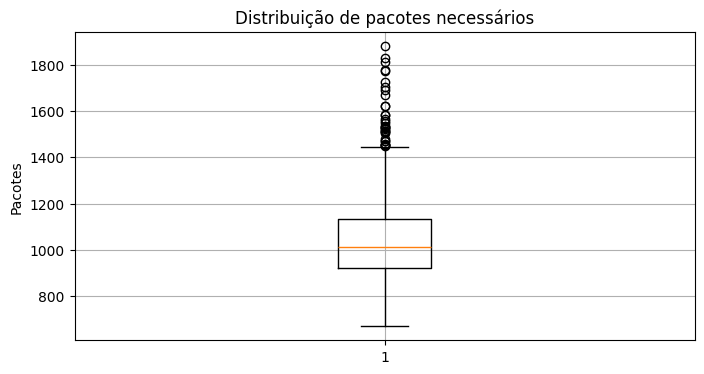

In [81]:
plt.figure(figsize=(8,4))

plt.boxplot(df["pacotes_comprados"])

plt.title('Distribuição de pacotes necessários')
plt.ylabel('Pacotes')

plt.grid(True)
plt.show()



---


#**6. 💰 Análise do Custo Total da Coleção**



####**6.1 Média**


In [22]:
media_custo = df["custo_total"].mean()

print(f'Média de custo: R${media_custo}')

Média de custo: R$7393.92




---


####**6.2 Custo mínimo e máximo**

In [21]:
custo_minimo = df["custo_total"].min()
custo_maximo = df["custo_total"].max()

print(f'Menor valor encontrado: R${custo_minimo}')
print(f'Maior valor encontrado: R${custo_maximo}')

Menor valor encontrado: R$4758
Maior valor encontrado: R$13242




---


####**6.3 Mediana**

In [24]:
mediana_custo = df["custo_total"].median()

print(f'Mediana dos custos: R$')

Mediana dos custos: R$7166.0




---


####**6.4 Quartis**

In [26]:
quartis_custo = df["custo_total"].quantile([0.25, 0.50, 0.75])

quartis_custo

,custo_total
0.25,6515.00
0.50,7166.00
0.75,7993.75




---


####**6.5 Análise da distribuição dos valores necessários para completar o álbum**

O histograma abaixo apresenta a distribuição do custo nas simulações.

Essa visualização permite observar se os valores ficaram concentrados próximos da média ou se houve grande variação entre os resultados.

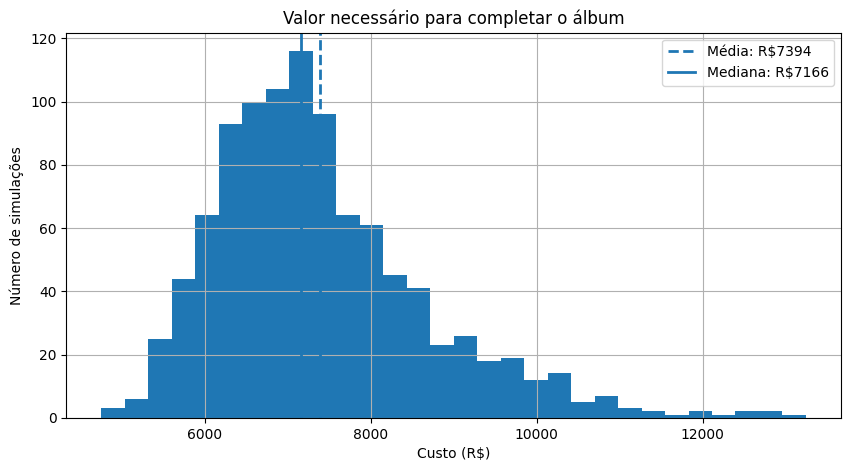

In [56]:
plt.figure(figsize=(10,5))

plt.hist(
    df["custo_total"], bins=30)

plt.axvline(
    media_custo,
    linestyle="--",
    linewidth=2,
    label=f"Média: R${media_custo:.0f}"
)

plt.axvline(
    mediana_custo,
    linestyle="-",
    linewidth=2,
    label=f"Mediana: R${mediana_custo:.0f}"
)

plt.title("Valor necessário para completar o álbum")
plt.xlabel("Custo (R$)")
plt.ylabel("Número de simulações")

plt.legend()
plt.grid(True)
plt.show()



---


####**6.6 Gráfico BloxPlot**

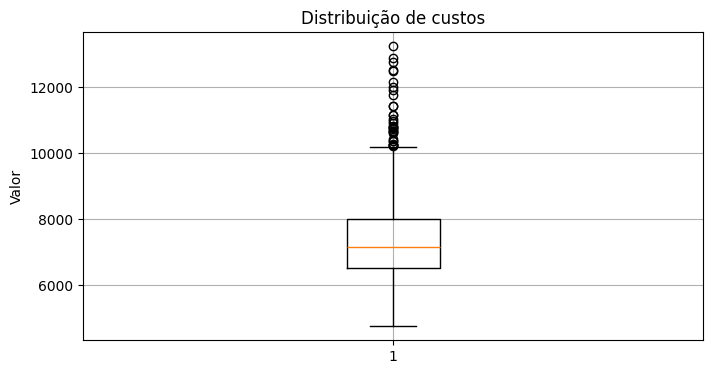

In [51]:
plt.figure(figsize=(8,4))

plt.boxplot(df["custo_total"])

plt.title("Distribuição de custos")
plt.ylabel("Valor")

plt.grid(True)
plt.show()



---


#**7. 🔁 Análise das Figurinhas Repetidas**

Nesta etapa será analisada a quantidade de figurinhas repetidas geradas durante as simulações.

As figurinhas repetidas representam cromos comprados que já pertenciam à coleção do álbum, sendo um dos principais fatores que aumentam o custo final da coleção.

Serão analisados:

- Média de figurinhas repetidas totais
- Diferença entre repetidas normais e brilhantes
- Distribuição dos resultados

####**7.1 Média e mediana das repetidas totais**

In [94]:
media_repetidas = df["repetidas_total"].mean()

print(f'Média de figurinhas repetidas: {media_repetidas:.0f}')

Média de figurinhas repetidas: 6339


In [95]:
mediana_repetidas = df['repetidas_total'].median()


print(f'Mediana de figurinhas repetidas: {mediana_repetidas:.0f}')

Mediana de figurinhas repetidas: 6111


**Conclusão**

Como os dois valores apresentam uma diferença relativamente pequena, é possível observar que a distribuição das repetidas possui um comportamento equilibrado, sem grande influência de valores muito altos ou muito baixos.

Isso indica que, na maioria das simulações, a quantidade de figurinhas repetidas ficou próxima dessa faixa, mostrando que a geração de cromos duplicados é um comportamento esperado durante a tentativa de completar o álbum apenas através da compra de pacotes.

---


#### **7.2 Comparação entre Repetidas Normais e Brilhantes**



In [15]:
media_normais = df["repetidas_normais"].mean()
media_brilhantes = df["repetidas_brilhantes"].mean()

print(f"Média repetidas normais: {media_normais:.0f}")
print(f"Média repetidas brilhantes: {media_brilhantes:.0f}")

Média repetidas normais: 5898
Média repetidas brilhantes: 441


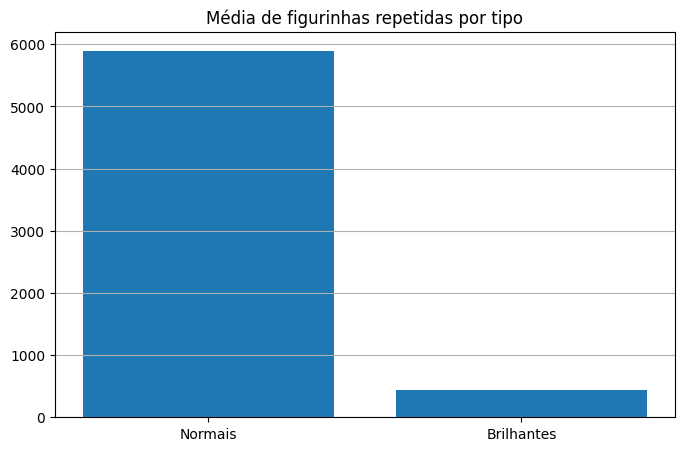

In [99]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Normais", "Brilhantes"],
    [media_normais, media_brilhantes]
)

plt.title("Média de figurinhas repetidas por tipo")

plt.grid(axis="y")
plt.show()

**Conclusão**

A comparação mostra que as figurinhas normais geram uma quantidade maior de repetidas em relação às brilhantes.

Isso ocorre principalmente porque os cromos normais representam a maior parte do álbum e possuem uma frequência maior de aparição nos pacotes.

---

####**7.3 Impacto das Repetidas na Coleção**

In [68]:
media_repetidas = df["repetidas_total"].mean()
media_pacotes = df["pacotes_comprados"].mean()

figurinhas_compradas = media_pacotes * 7
percentual_repetidas = (media_repetidas / figurinhas_compradas) * 100

print(f"Percentual médio de repetidas: {percentual_repetidas:.2f}%")

Percentual médio de repetidas: 86.61%


**Conclusão**

Os resultados mostram que aproximadamente **86%** das figurinhas obtidas durante as simulações eram repetidas.

Esse resultado evidencia como a aleatoriedade dos pacotes aumenta a dificuldade da coleção, já que uma parte significativa dos cromos adquiridos não preenche novos espaços no álbum.


---



#**8. 🧾 Variação de Custos das simulações**

Para analisar como os custos variaram entre as 1000 simulações realizadas, foi utilizado um gráfico de linha contendo os valores da coluna `custo_total` ordenados em ordem crescente.



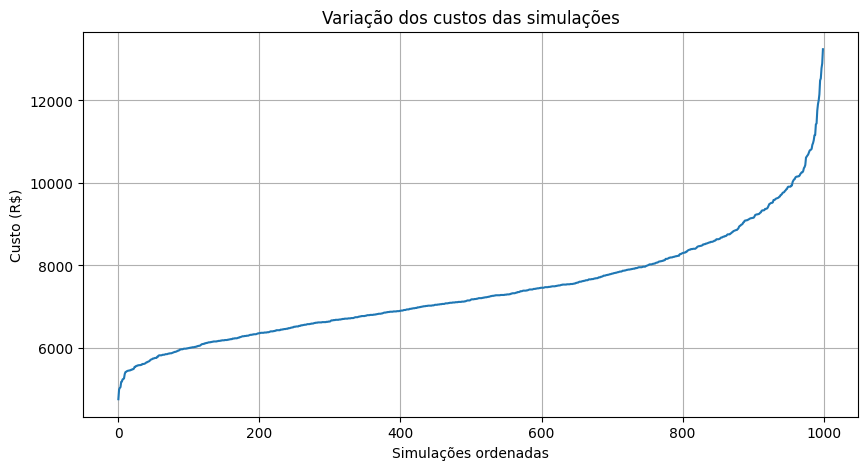

In [52]:
plt.figure(figsize=(10,5))

plt.plot(
    df["custo_total"].sort_values().values
)

plt.title("Variação dos custos das simulações")
plt.xlabel("Simulações ordenadas")
plt.ylabel("Custo (R$)")

plt.grid(True)
plt.show()

**Conclusão**

O gráfico mostrou que existe uma diferença significativa entre os resultados das simulações. Embora a maior parte dos custos esteja concentrada em uma faixa intermediária, algumas simulações apresentaram valores consideravelmente mais altos, evidenciando o impacto da aleatoriedade na obtenção das figurinhas.

Observa-se que completar o álbum sem realizar trocas pode gerar custos bastante distintos entre os participantes, mesmo partindo das mesmas condições iniciais. Isso ocorre porque algumas simulações encontram as figurinhas faltantes mais rapidamente, enquanto outras acumulam uma grande quantidade de repetidas antes de completar o álbum.

Dessa forma, conclui-se que o fator sorte exerce influência direta no custo final do álbum, podendo aumentar significativamente o investimento necessário em determinados casos.



---



# **9. 🔗 Matriz de correlação**

A matriz de correlação foi utilizada para medir o grau de relacionamento entre as variáveis do conjunto de dados. Para isso, foi calculada a correlação entre todas as colunas numéricas utilizando o método `corr()`.

Os valores da matriz variam entre -1 e 1:

- **1**: correlação positiva perfeita.
- **0**: ausência de correlação.
- **-1**: correlação negativa perfeita.

Valores próximos de 1 indicam que as variáveis tendem a aumentar juntas, enquanto valores próximos de -1 indicam que uma variável tende a diminuir quando a outra aumenta.

A visualização facilita a identificação de relações entre variáveis como quantidade de pacotes comprados, custo total e número de figurinhas repetidas.

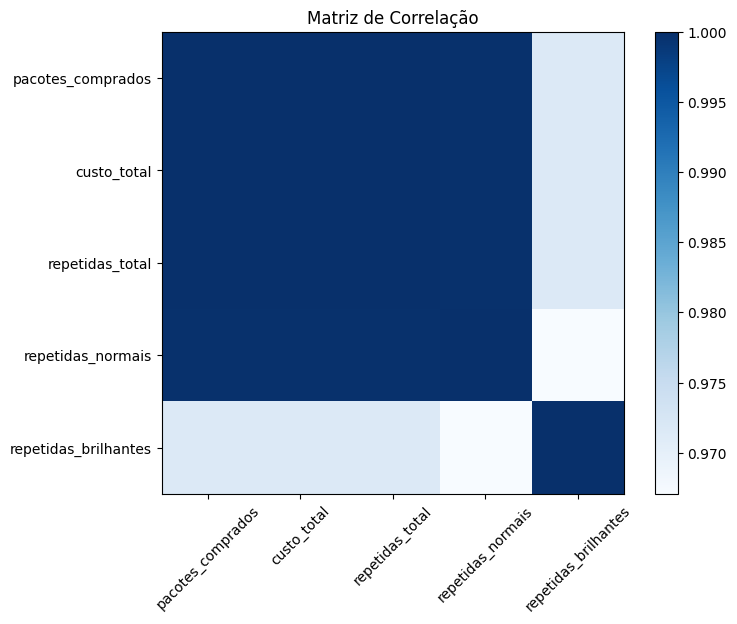

In [58]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de Correlação")
plt.show()

**Conclusão**

A análise da matriz de correlação mostrou uma forte relação positiva entre as variáveis do estudo.

Esse comportamento era esperado, pois quanto maior o número de pacotes adquiridos, maior será o gasto necessário para completar o álbum e maior será a quantidade de figurinhas repetidas acumuladas ao longo do processo.

Os resultados indicam que essas variáveis são fortemente dependentes entre si, evidenciando que o custo e a quantidade de repetidas são consequências diretas do número de pacotes necessários para completar o álbum.